# Chapter 2b — Scoring methodology

Translated from the scoring-construction, scoring-evaluation, and
sustainability-index scripts of `HSF/2. ESG Scoring/*.m` (Roncalli,
*Handbook of Sustainable Finance*): `chap2_scoring1-10.m`,
`chap2_scoring_shannon1-2.m`, `chap2_lpi1.m`, `chap2_rli1.m` (the
weight-aggregation, distribution, and framework scripts), plus
`chap2_scoring_gini1-2.m`, `chap2_scoring_graphical1-3.m`,
`chap2_scoring_ks1.m` and `chap2_scoring_backtesting1-5.m` (the
evaluation-curve and backtesting scripts).

The rating-scale and Markov-transition material is in
[`02a_ratings_and_transitions.ipynb`](02a_ratings_and_transitions.ipynb)
instead.

**A note on the evaluation-curve scripts.** For `gini1-2`, `graphical1-3`
and `ks1`, the `chap2_*.m` scripts only *plot* a `curve_gini`/
`performance_curve`/... matrix that is loaded from a `.mat` file; the
`Data/*.m` "data-prep" scripts that build those `.mat` files are, in turn,
thin `xlsread(...) -> save(.mat)` converters with no computation in them.
The actual curve-generating formulas exist nowhere in the MATLAB source --
only the finished numbers, baked into the `.xlsx` files. Rather than
guess at an unstated formula, this notebook reads those `.xlsx` files
directly (same provenance style as the transition matrices in Chapter 2a)
and reproduces the book's figures from the real numbers, with column
semantics taken from each plotting script's own variable/legend names
(verified against the `.xlsx` structure below, not assumed). `gini1` is
the one exception: its curve is a pure textbook illustration ($x$,
$x^3$-like power curve, and a step function), not real data, and is
reproduced from first principles instead.

The `scoring_backtesting*.m` scripts *do* contain real computation -- a
MATLAB `csaps` smoothing-spline pass over precomputed accuracy/F1/MCC/
Shannon-agreement curves -- translated here using the
[`csaps`](https://pypi.org/project/csaps/) package, a MATLAB-compatible
Python implementation of the same smoothing-spline algorithm.

Per the project's current policy, no decision has been made about
porting any function from this notebook into `quanttoolbox` -- reusable
candidates are tracked in
[`PACKAGING_CANDIDATES.md`](../../PACKAGING_CANDIDATES.md) instead, to be
revisited later, after checking for existing prior art elsewhere.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from csaps import csaps

from quanttoolbox.stats.distributions import (
    bates_cdf, bates_pdf, beta_cdf, beta_pdf,
    constant_correlation_matrix, normal_cdf, normal_ppf,
)
from quanttoolbox.sustainable_finance.entropy import shannon_entropy

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


## 1. Weight aggregation

From `chap2_scoring1.m`. A two-level weighting scheme: six criteria are
first combined (via `omega1`, 6x3) into three pillars, which are then
combined (via `omega0`, equal-weighted) into a single score. `omega1
@ omega0` gives the criteria's implied weight in the final score
directly.


In [2]:
omega1 = np.array([
    [0.50, 0.00, 0.00],
    [0.25, 0.00, 0.00],
    [0.25, 0.25, 0.00],
    [0.00, 0.25, 0.00],
    [0.00, 0.50, 0.00],
    [0.00, 0.00, 1.00],
])
omega0 = np.ones(3) / 3

omega = omega1 @ omega0
pd.DataFrame({"omega": omega, "omega (in bp of 12)": 12 * omega})


,omega,omega (in bp of 12)
0,0.166667,2.0
1,0.083333,1.0
2,0.166667,2.0
3,0.083333,1.0
4,0.166667,2.0
5,0.333333,4.0


## 2. Variance propagation through the aggregation

From `chap2_scoring2.m`. Same idea with a (slightly different) weight
matrix, but now propagating variance: if the six criteria $X_j$ are iid
$\mathcal{N}(0,1)$, what is the distribution of each pillar score
$\mathcal{S}_k^{(1)} = \omega_{1,\cdot k}^\top X$ and of the final score
$\mathcal{S} = \omega^\top X$? Since the $X_j$ are independent,
$\mathrm{Var}(\mathcal{S}_k^{(1)}) = \sum_j \omega_{1,jk}^2$.


In [3]:
omega1 = np.array([
    [0.50, 0.00, 0.00],
    [0.25, 0.00, 0.00],
    [0.25, 0.00, 0.00],
    [0.00, 0.50, 0.00],
    [0.00, 0.50, 0.00],
    [0.00, 0.00, 1.00],
])
omega0 = np.ones(3) / 3
omega = omega1 @ omega0

mu = np.zeros(6)
sigma = np.ones(6)
Sigma = np.diag(sigma**2)

mu_level1 = omega1.T @ mu
Sigma_level1 = omega1.T @ Sigma @ omega1
sigma_level1 = np.sqrt(np.diag(Sigma_level1))

mu_level0 = omega.T @ mu
sigma_level0 = float(np.sqrt(omega.T @ Sigma @ omega))

all_mu = np.concatenate([[mu[0]], mu_level1, [mu_level0]])
all_sigma = np.concatenate([[sigma[0]], sigma_level1, [sigma_level0]])
pd.DataFrame({"mu": all_mu, "sigma": all_sigma},
             index=["X_j", "S1(1)", "S2(1)", "S3(1)", "S"])


,mu,sigma
X_j,0.0,1.000000
S1(1),0.0,0.612372
S2(1),0.0,0.707107
S3(1),0.0,1.000000
S,0.0,0.456435


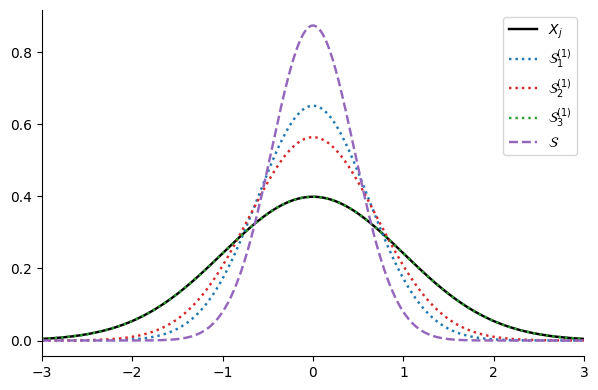

In [4]:
labels = [r"$X_j$", r"$\mathcal{S}_1^{(1)}$", r"$\mathcal{S}_2^{(1)}$",
          r"$\mathcal{S}_3^{(1)}$", r"$\mathcal{S}$"]
styles = ["-", ":", ":", ":", "--"]
colours = ["black", "tab:blue", "tab:red", "tab:green", "tab:purple"]

x = np.linspace(-3, 3, 601)
fig, ax = plt.subplots(figsize=(7, 4.5))
for mu_i, sigma_i, lbl, ls, c in zip(all_mu, all_sigma, labels, styles, colours):
    ax.plot(x, stats.norm.pdf(x, mu_i, sigma_i), ls, color=c, lw=1.75, label=lbl)
ax.set_xlim(-3, 3)
ax.legend()
plt.show()


## 3. Rescaling a raw score into $[0, 1]$: a two-case geometry

From `chap2_scoring3.m`. A purely geometric illustration (no formula
beyond the coordinates plotted in the original script) of how a min-max
style rescaling onto $[0,1]\times[0,1]$ behaves differently depending on
whether the clipping/scaling parameter $s$ falls below or above $0.5$:
case (a), $0 \le s \le 0.5$, versus case (b), $0.5 \le s \le 1$. The
shaded region is the feasible zone described by the construction at each
$s$.


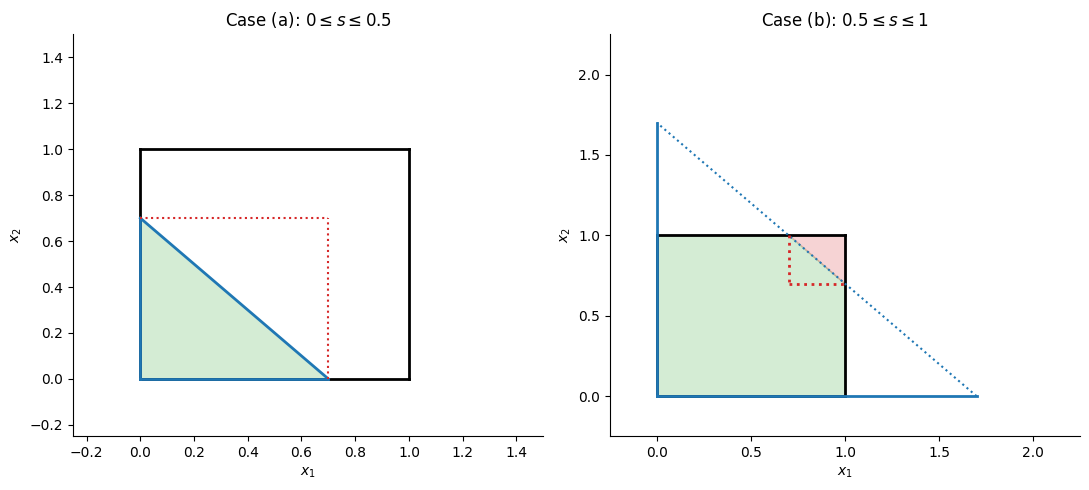

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Case (a): 0 <= s <= 0.5
ax = axes[0]
s = 0.35
for x0, y0, x1, y1 in [(0, 1, 1, 1), (1, 0, 1, 1), (0, 0, 0, 1), (0, 0, 1, 0)]:
    ax.plot([x0, x1], [y0, y1], "-", color="black", lw=2.0)
ax.plot([2 * s, 0], [0, 2 * s], "-", color="tab:blue", lw=2.0)
ax.plot([0, 0], [0, 2 * s], "-", color="tab:blue", lw=2.0)
ax.plot([0, 2 * s], [0, 0], "-", color="tab:blue", lw=2.0)
ax.plot([2 * s, 2 * s], [0, 2 * s], ":", color="tab:red", lw=1.5)
ax.plot([0, 2 * s], [2 * s, 2 * s], ":", color="tab:red", lw=1.5)
ax.fill([0, 0, 2 * s], [0, 2 * s, 0], color="tab:green", alpha=0.2)
ax.set_title(r"Case (a): $0 \leq s \leq 0.5$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_xlim(-0.25, 1.5)
ax.set_ylim(-0.25, 1.5)

# Case (b): 0.5 <= s <= 1
ax = axes[1]
s = 0.85
for x0, y0, x1, y1 in [(0, 1, 1, 1), (1, 0, 1, 1), (0, 0, 0, 1), (0, 0, 1, 0)]:
    ax.plot([x0, x1], [y0, y1], "-", color="black", lw=2.0)
ax.plot([2 * s, 0], [0, 2 * s], ":", color="tab:blue", lw=1.5)
ax.plot([0, 0], [0, 2 * s], "-", color="tab:blue", lw=2.0)
ax.plot([0, 2 * s], [0, 0], "-", color="tab:blue", lw=2.0)
ax.plot([2 * s - 1, 2 * s - 1], [1, 2 * s - 1], ":", color="tab:red", lw=2.0)
ax.plot([2 * s - 1, 1], [2 * s - 1, 2 * s - 1], ":", color="tab:red", lw=2.0)
v = np.array([[0, 0], [1, 0], [1, 2 * s - 1], [2 * s - 1, 1], [0, 1]])
ax.fill(v[:, 0], v[:, 1], color="tab:green", alpha=0.2)
v2 = np.array([[1, 2 * s - 1], [1, 1], [2 * s - 1, 1]])
ax.fill(v2[:, 0], v2[:, 1], color="tab:red", alpha=0.2)
ax.set_title(r"Case (b): $0.5 \leq s \leq 1$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_xlim(-0.25, 2.25)
ax.set_ylim(-0.25, 2.25)

plt.tight_layout()
plt.show()


## 4. The Bates distribution

From `chap2_scoring4.m`-`chap2_scoring5.m`. The Bates distribution is the
distribution of the mean of $m$ iid $\mathcal{U}(0,1)$ variables -- a
natural model for a score obtained by averaging $m$ uniformly-distributed
sub-scores. As $m$ grows, it concentrates around $0.5$ (a discrete
illustration of the central limit theorem). Uses `quanttoolbox`'s
`bates_pdf`/`bates_cdf` (ported from the HSF toolbox's own
`pdfBates.m`/`cdfBates.m` -- there is no `scipy` equivalent).


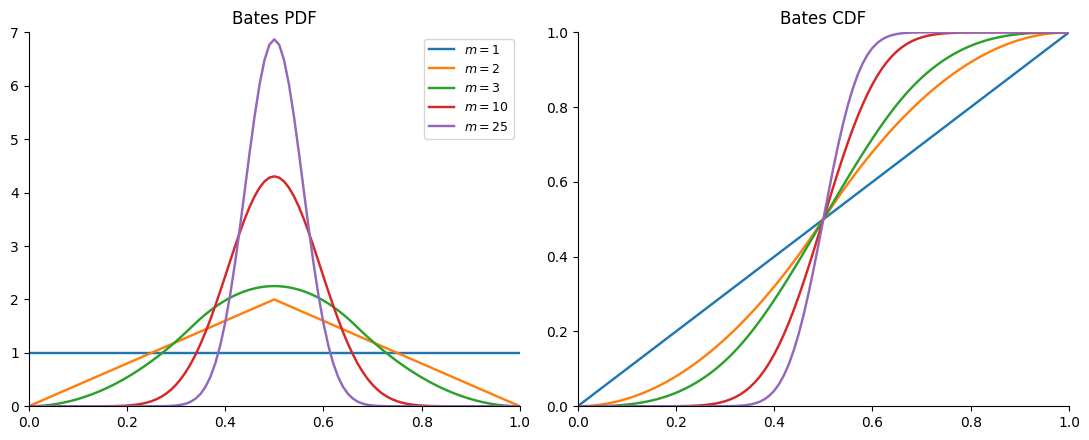

In [6]:
x = np.linspace(0, 1, 101)
ms = [1, 2, 3, 10, 25]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for m in ms:
    axes[0].plot(x, bates_pdf(x, m), lw=1.75, label=f"$m={m}$")
    axes[1].plot(x, bates_cdf(x, m), lw=1.75, label=f"$m={m}$")
axes[0].set_title("Bates PDF")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 7)
axes[0].legend(fontsize=9)
axes[1].set_title("Bates CDF")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 5. Basket variance under a constant-correlation model

From `chap2_scoring6.m`. For a weighted score $\mathcal{S} =
\omega^\top X$ built from $m$ criteria with unit variance and constant
pairwise correlation $\rho$ (correlation matrix $C$), the variance
$\omega^\top C \omega$ has two convenient closed forms:
$\rho\,(e^\top \omega\omega^\top e) + (1-\rho)\,\omega^\top\omega =
\rho\, s^2 + (1-\rho)\,\omega^\top\omega$ where $s = \sum_i \omega_i$;
and, for equal weights $\omega_i = 1/m$, it simplifies further to
$\rho + (1-\rho)/m$. Verified numerically for both a random weight
vector and the equal-weight case.


In [7]:
rng = np.random.default_rng(0)
m = 10
rho = 0.30
e = np.ones(m)
C = constant_correlation_matrix(m, rho)

omega = rng.random(m)
s = omega.sum()
var1 = omega @ C @ omega
var2 = rho * (e @ np.outer(omega, omega) @ e) + (1 - rho) * (omega @ omega)
var3 = rho * s**2 + (1 - rho) * (omega @ omega)
print("random weights:", [var1, var2, var3])

omega = np.ones(m) / m
var1 = omega @ C @ omega
var2 = rho + (1 - rho) / m
print("equal weights:  ", [var1, var2])


random weights: [np.float64(11.923389076892748), np.float64(11.92338907689275), np.float64(11.92338907689275)]
equal weights:   [np.float64(0.36999999999999994), 0.37]


## 6. Vasicek-style confidence bands for the basket score

From `chap2_scoring7.m`. Continuing the constant-correlation model with
equal weights, $\mathrm{Var}(\mathcal{S}) = \rho + (1-\rho)/m$, so a
$100\alpha\%$ confidence band for the (standardised) basket score is
$\pm c\,\sigma$ with $c = \Phi^{-1}\left(\frac{1+\alpha}{2}\right)$. Shown
as a function of $\rho$ for basket sizes $m \in \{1, 3, 10, 100\}$.


c = 3.0233


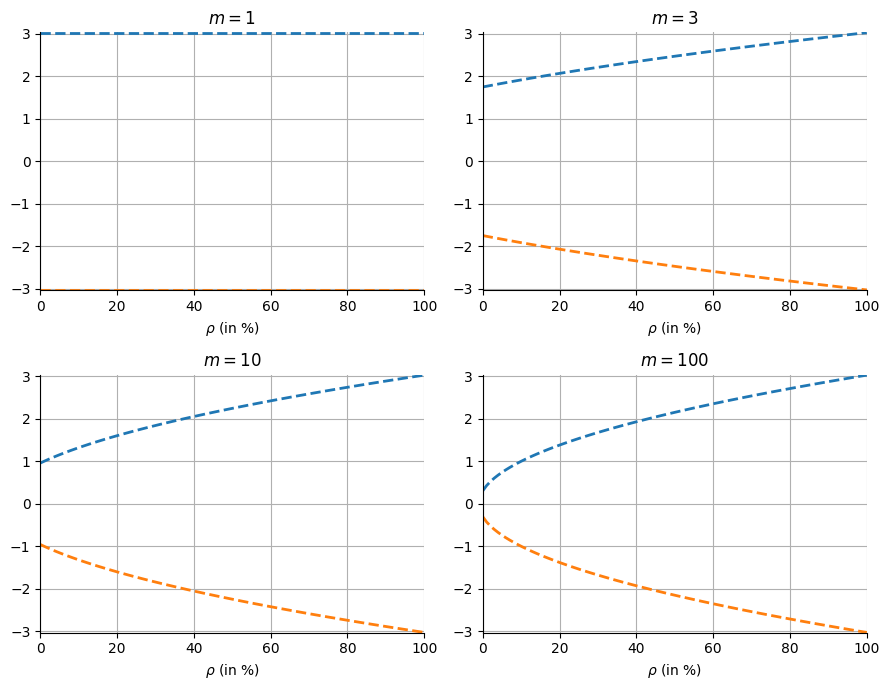

rho=0.20, m=20: band = [-1.4811, 1.4811]


In [8]:
alpha = 0.9975
c = normal_ppf((1 + alpha) / 2)
print(f"c = {c:.4f}")

rho = np.linspace(0, 1, 101)
ms = [1, 3, 10, 100]

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, m in zip(axes.ravel(), ms):
    sigma = np.sqrt(rho + (1 - rho) / m)
    ax.plot(100 * rho, c * sigma, "--", lw=2.0)
    ax.plot(100 * rho, -c * sigma, "--", lw=2.0)
    ax.grid(True)
    ax.set_title(f"$m = {m}$")
    ax.set_xlabel(r"$\rho$ (in %)")
    ax.set_xlim(0, 100)
    ax.set_ylim(-3.03, 3.03)
plt.tight_layout()
plt.show()

rho, m = 0.20, 20
sigma = np.sqrt(rho + (1 - rho) / m)
print(f"rho=0.20, m=20: band = [{-c*sigma:.4f}, {c*sigma:.4f}]")


## 7. Beta-distribution score transform

From `chap2_scoring8.m`. A raw score $x \sim \mathcal{N}(\mu, \sigma^2)$
can be transformed onto $[0,1]$ via $s = \varphi(x) = F_\beta^{-1}\!
\left(\Phi\left(\frac{x-\mu}{\sigma}\right); \alpha, \beta\right)$: first
to a uniform via the normal CDF, then to a score with a chosen shape via
the Beta quantile function. $\alpha=\beta=2$ gives a symmetric,
concentrating transform; $\alpha=\beta=7$ concentrates more sharply
around $0.5$; $\alpha=2.5,\beta=1.5$ skews the score upward.


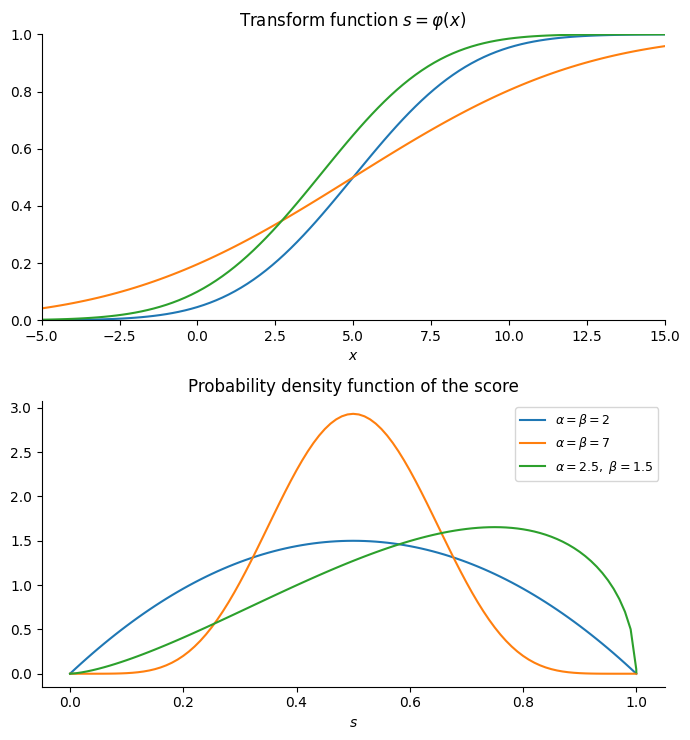

In [9]:
mu, sigma = 5, 2
x = np.linspace(-5, 15, 101)
p = normal_cdf((x - mu) / sigma)

shapes = [(2, 2), (7, 7), (2.5, 1.5)]
ys = [stats.beta.ppf(p, a, b) for a, b in shapes]

u = np.concatenate([[1e-4], np.linspace(0.01, 0.99, 99), [0.9999, 0.99999]])
pdfs = [beta_pdf(u, a, b) for a, b in shapes]

fig, axes = plt.subplots(2, 1, figsize=(7, 7.5))
labels = [r"$\alpha=\beta=2$", r"$\alpha=\beta=7$", r"$\alpha=2.5,\ \beta=1.5$"]
for y, lbl in zip(ys, labels):
    axes[0].plot(x, y, lw=1.5, label=lbl)
axes[0].set_title(r"Transform function $s = \varphi(x)$")
axes[0].set_xlabel("$x$")
axes[0].set_xlim(-5, 15)
axes[0].set_ylim(0, 1)

for pdf, lbl in zip(pdfs, labels):
    axes[1].plot(u, pdf, lw=1.5, label=lbl)
axes[1].set_title("Probability density function of the score")
axes[1].set_xlabel("$s$")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


## 8. A scoring and aggregation framework: $q$, $z$, $qz$, $zq$, $bz$

From `chap2_scoring9.m`. Six ways to turn a raw criterion $x$ into a
score, all standardising to a common, comparable scale:

- **$q$-score**: the rescaled rank, $q = \mathrm{rank}(x) / (n+1)$
  (times a `scaling` factor, e.g. 100).
- **$z$-score**: the usual standardisation, $z = (x - \bar{x}) / s_x$.
- **$qz$**: the $z$-score mapped through the normal CDF, $qz = \Phi(z)$
  (times `scaling`) -- a "$q$-score built from $z$" rather than from raw
  ranks.
- **$zq$**: the reverse -- the $q$-score mapped through the normal
  quantile function, $zq = \Phi^{-1}(q)$.
- **$bz$** / **$bz\_skew$**: the $z$-score's normal-CDF transform mapped
  through a Beta quantile function ($\alpha=\beta=2$, resp.
  $\alpha=2.5,\beta=1.5$ for a skewed version) -- combining $qz$'s idea
  with `scoring8`'s Beta-shaped transform.

Two criteria $x_1, x_2$ are scored each of the six ways, aggregated
$0.7\,x_1 + 0.3\,x_2$ in each of the six score spaces, and re-scored/
ranked once more -- illustrating how the choice of scoring function
changes the final ranking of the same underlying data.


In [10]:
def qscore(x, scaling=1.0):
    # Rescaled-rank score: rank(x) / (n + 1), times `scaling`.
    x = np.asarray(x, dtype=float)
    q = stats.rankdata(x) / (len(x) + 1)
    return scaling * q


def zscore(x):
    # Standard z-score: (x - mean(x)) / std(x).
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std()


def aggregate(s1, s2, w1, w2):
    # Weighted aggregation of two already-computed scores.
    return w1 * np.asarray(s1) + w2 * np.asarray(s2)


def qz_score(x, scaling=1.0):
    # z-score mapped through the normal CDF, times `scaling`.
    return scaling * normal_cdf(zscore(x))


def zq_score(x):
    # q-score (scaling=1) mapped through the normal quantile function.
    return normal_ppf(qscore(x, 1.0))


def bz_score(x, a=2.0, b=2.0):
    # z-score -> normal CDF -> Beta(a, b) quantile function.
    u = normal_cdf(zscore(x))
    return stats.beta.ppf(u, a, b)


def summarise(**scores):
    return pd.DataFrame({name: [np.mean(s), np.std(s)] for name, s in scores.items()},
                         index=["mean", "std"])


In [11]:
x1 = np.array([94.0, 38.6, 30.6, 74.4, 97.1, 57.1, 132.4, 92.5, 64.9])
x2 = np.array([-3.0, -5.5, 5.6, -1.3, -16.8, -3.5, 8.5, -9.1, -4.6])
scaling = 100

scorers = {
    "q": lambda x: qscore(x, scaling),
    "z": zscore,
    "qz": lambda x: qz_score(x, scaling),
    "zq": zq_score,
    "bz": lambda x: bz_score(x, 2, 2),
    "bz_skew": lambda x: bz_score(x, 2.5, 1.5),
}

s1 = {name: f(x1) for name, f in scorers.items()}
s2 = {name: f(x2) for name, f in scorers.items()}
w1, w2 = 0.7, 0.3
s12 = {name: aggregate(s1[name], s2[name], w1, w2) for name in scorers}
# Re-score the aggregate in its own space (matches chap2_scoring9.m).
s_final = {
    "q": qscore(s12["q"], scaling), "z": zscore(s12["z"]),
    "qz": qz_score(s12["qz"], scaling), "zq": zq_score(s12["zq"]),
    "bz": bz_score(s12["bz"], 2, 2), "bz_skew": bz_score(s12["bz_skew"], 2.5, 1.5),
}

pd.DataFrame({
    "x1": x1, "q(x1)": s1["q"], "x2": x2, "q(x2)": s1["q"] * 0 + s2["q"],
    "0.7 q1+0.3 q2": s12["q"], "q(final)": s_final["q"],
    "rank": stats.rankdata(-s_final["q"]).astype(int),
})


,x1,q(x1),x2,q(x2),0.7 q1+0.3 q2,q(final),rank
0,94.0,70.0,-3.0,60.0,67.0,80.0,2
1,38.6,20.0,-5.5,30.0,23.0,10.0,9
2,30.6,10.0,5.6,80.0,31.0,20.0,8
3,74.4,50.0,-1.3,70.0,56.0,60.0,4
4,97.1,80.0,-16.8,10.0,59.0,70.0,3
5,57.1,30.0,-3.5,50.0,36.0,30.0,7
6,132.4,90.0,8.5,90.0,90.0,90.0,1
7,92.5,60.0,-9.1,20.0,48.0,50.0,5
8,64.9,40.0,-4.6,40.0,40.0,40.0,6


In [12]:
summarise(**{f"{name} (final)": s for name, s in s_final.items()})


,q (final),z (final),qz (final),zq (final),bz (final),bz_skew (final)
mean,50.000000,-2.467162e-17,47.843560,-6.167906e-18,0.487181,0.617828
std,25.819889,1.000000e+00,28.203572,7.731439e-01,0.215399,0.207195


## 9. Applying the framework: CEO pay-ratio scores

From `chap2_scoring10.m`. The $q$/$z$-score framework applied to real
data: 2021 US CEO-to-median-employee pay ratios (SEC disclosures,
`pay_ratio_2021.xlsx`). $X_1$ is the raw pay ratio; $X_2$ is its log --
pay ratios are heavily right-skewed (a handful of firms report
ratios in the thousands), so comparing the $z$-score of the raw ratio to
the $z$-score of the log illustrates why scoring functions need to be
robust to that skew.


2518 companies, pay ratio range: [1.1, 22091.6]


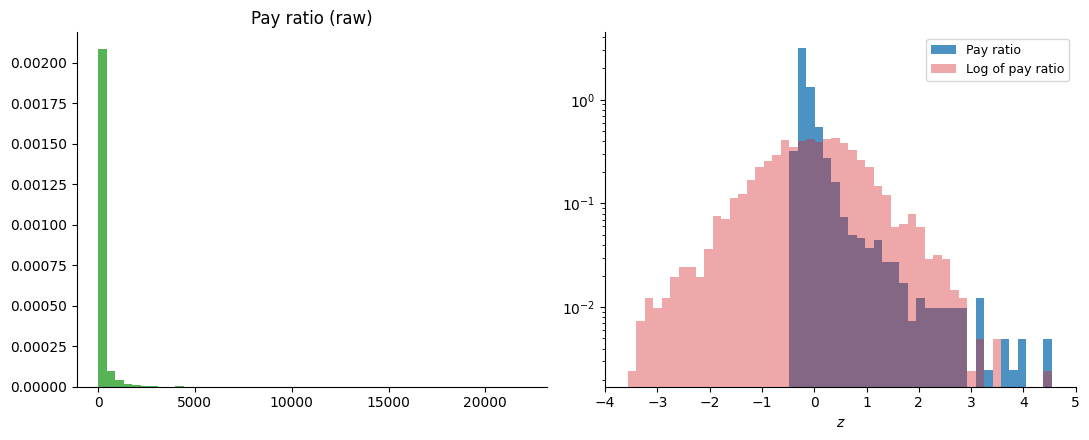

In [13]:
pay_ratio_raw = pd.read_excel(f"{DATA_DIR}/pay_ratio_2021.xlsx", sheet_name="FY 2021 Ratios")
pay_ratio = pay_ratio_raw["Pay Ratio"].to_numpy(dtype=float)
pay_ratio = pay_ratio[pay_ratio > 1]
print(f"{len(pay_ratio)} companies, pay ratio range: [{pay_ratio.min():.1f}, {pay_ratio.max():.1f}]")

x1 = pay_ratio
x2 = np.log(pay_ratio)
z1 = zscore(x1)
z2 = zscore(x2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(x1, bins=50, density=True, color="tab:green", alpha=0.8)
axes[0].set_title("Pay ratio (raw)")

_, edges = np.histogram(z2, bins=50)
axes[1].hist(z1, bins=edges, density=True, color="tab:blue", alpha=0.8, label="Pay ratio")
axes[1].hist(z2, bins=50, density=True, color="tab:red", alpha=0.4, label="Log of pay ratio")
axes[1].set_xlabel("$z$")
axes[1].set_xlim(-4, 5)
axes[1].set_yscale("log")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


## 10. Shannon-entropy scoring

From `chap2_scoring_shannon1.m`-`chap2_scoring_shannon2.m`. Uses
`quanttoolbox.sustainable_finance.entropy.shannon_entropy`, already
ported from the HSF toolbox's `shannon_entropy.m` (see Chapter 2a). For a
joint distribution $P$ over (score bucket, outcome), it returns the
marginal entropy of each side, their mutual information, and their joint
entropy -- a way of scoring how much a rating/score bucketing actually
tells you about the outcome, without assuming any particular model.

`shannon1` applies this to four illustrative 6x6 joint distributions
(varying degrees of association); `shannon2` applies it to two 6x5
"confusion matrices" of realised counts.


In [14]:
P1 = np.ones((6, 6)) / 36

P2 = np.zeros((6, 6))
np.fill_diagonal(P2, 1 / 6)

P3 = np.zeros((6, 6))
P3[0, 0] = P3[0, 1] = 1 / 24
P3[1, 0] = P3[1, 1] = P3[1, 2] = 1 / 24
P3[1, 3] = 1 / 48
P3[2, 1] = 1 / 24
P3[2, 2] = 1 / 6
P3[2, 3] = 1 / 24
P3[2, 4] = 1 / 48
P3[3, 1] = 1 / 48
P3[3, 2] = 1 / 24
P3[3, 3] = 1 / 6
P3[3, 4] = 1 / 24
P3[4, 2] = 1 / 48
P3[4, 3] = 1 / 24
P3[4, 4] = 1 / 24
P3[4, 5] = 1 / 24
P3[5, 4] = 1 / 24
P3[5, 5] = 1 / 24

P4 = np.zeros((6, 6))
P4[0, 5] = 1 / 12
P4[1, 3] = 1 / 8
P4[1, 0] = 1 / 8
P4[2, 1] = 1 / 24
P4[3, 2] = 1 / 24
P4[3, 0] = 5 / 24
P4[4, 4] = 1 / 24
P4[4, 0] = 3 / 24
P4[5, 0] = 3 / 24
P4[5, 1] = 1 / 24
P4[5, 2] = 1 / 24

rows = []
for name, P in [("P1 (uniform)", P1), ("P2 (diagonal)", P2),
                 ("P3 (banded)", P3), ("P4 (sparse)", P4)]:
    i_x, i_y, i_xy, i_x_y = shannon_entropy(P)
    rows.append({"matrix": name, "I(X)": i_x, "I(Y)": i_y,
                 "I(X,Y)": i_xy, "I(X int Y)": i_x_y})
pd.DataFrame(rows).round(3)


,matrix,I(X),I(Y),"I(X,Y)",I(X int Y)
0,P1 (uniform),1.792,1.792,-0.000,3.584
1,P2 (diagonal),1.792,1.792,1.792,1.792
2,P3 (banded),1.683,1.683,0.593,2.774
3,P4 (sparse),1.658,1.328,0.750,2.236


In [15]:
CT1 = np.array([
    [10, 9, 0, 0, 0],
    [7, 9, 0, 0, 0],
    [3, 0, 7, 2, 0],
    [0, 2, 10, 4, 5],
    [0, 0, 0, 10, 2],
    [0, 0, 3, 4, 13],
], dtype=float)
CT2 = np.array([
    [7, 10, 0, 0, 0],
    [10, 8, 0, 0, 0],
    [0, 0, 5, 4, 3],
    [3, 0, 10, 6, 4],
    [0, 2, 0, 5, 8],
    [0, 0, 5, 5, 5],
], dtype=float)

rows = []
for name, CT in [("Table 1", CT1), ("Table 2", CT2)]:
    P = CT / CT.sum()
    i_x, i_y, i_xy, i_x_y = shannon_entropy(P)
    rows.append({"table": name, "I(X)": i_x, "I(Y)": i_y,
                 "I(X,Y)": i_xy, "I(X int Y)": i_x_y})
pd.DataFrame(rows).round(3)


,table,I(X),I(Y),"I(X,Y)",I(X int Y)
0,Table 1,1.767,1.609,0.763,2.614
1,Table 2,1.771,1.609,0.636,2.745


## 11. The Lorenz/Gini curve, illustrated

From `chap2_scoring_gini1.m`. The classic Gini-coefficient construction:
plot the *perfect equality* line ($y=x$), a *Lorenz curve* $y =
\mathcal{S}(x)$ describing how concentrated an outcome actually is, and
the *perfect concentration* curve (a step function: nothing until the
very last unit, which gets everything). Region A (between perfect
equality and the Lorenz curve) versus region B (between the Lorenz curve
and perfect concentration) gives the Gini coefficient, $A / (A+B)$.

This is the one evaluation-curve script that is a pure textbook
illustration rather than real data: the Lorenz curve here is simply
$y = x^3$ (verified against `scoring_gini1.xlsx` to full precision), a
convenient convex curve for the diagram, not an estimate from any actual
score.


Area A (equality - Lorenz): 0.2500
Gini coefficient (2 x area A): 0.5000


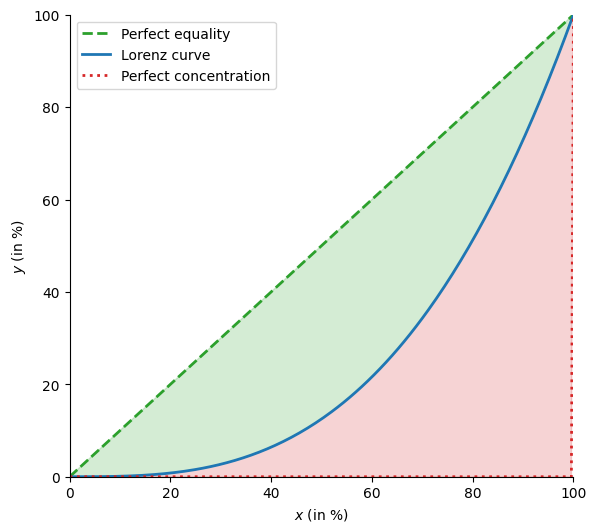

In [16]:
x = np.linspace(0, 1, 251)
perfect_equality = x
lorenz = x**3
perfect_concentration = np.where(x >= 1.0, 1.0, 0.0)

curve_gini = pd.read_excel(f"{DATA_DIR}/scoring_gini1.xlsx", header=None).to_numpy()
assert np.allclose(curve_gini[:, 1], perfect_equality, atol=1e-6)
assert np.allclose(curve_gini[:, 2], lorenz, atol=1e-6)
assert np.allclose(curve_gini[:, 3], perfect_concentration, atol=1e-6)

from scipy.integrate import trapezoid

area_A = trapezoid(perfect_equality - lorenz, x)
# Standard construction: the triangle under the perfect-equality line has
# area 0.5, so Gini = area A (equality - Lorenz) / 0.5 = 2 * area A.
gini = 2 * area_A
print(f"Area A (equality - Lorenz): {area_A:.4f}")
print(f"Gini coefficient (2 x area A): {gini:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(100 * x, 100 * perfect_equality, "--", color="tab:green", lw=2.0, label="Perfect equality")
ax.plot(100 * x, 100 * lorenz, "-", color="tab:blue", lw=2.0, label="Lorenz curve")
ax.plot(100 * x, 100 * perfect_concentration, ":", color="tab:red", lw=2.0, label="Perfect concentration")
ax.fill(np.concatenate([100 * x, 100 * x[::-1]]),
        np.concatenate([100 * perfect_equality, 100 * lorenz[::-1]]),
        color="tab:green", alpha=0.2)
ax.fill(np.concatenate([100 * x, 100 * x[::-1]]),
        np.concatenate([100 * lorenz, 100 * perfect_concentration[::-1]]),
        color="tab:red", alpha=0.2)
ax.set_xlabel("$x$ (in %)")
ax.set_ylabel("$y$ (in %)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(loc="upper left", fontsize=10)
plt.show()


## 12. Selection, precision and ROC curves

From `chap2_scoring_gini2.m`. Three Gini-style area diagrams for
different evaluation curves -- a *selection curve*, a *precision curve*
and a *ROC curve* -- each read directly from `scoring_gini2.xlsx`
(one sheet per curve, columns `[x1, x2, y1, y2]`; a synthetic diagonal
$y=x$ is added as the third, reference curve in each panel, matching
`chap2_scoring_gini2.m`).


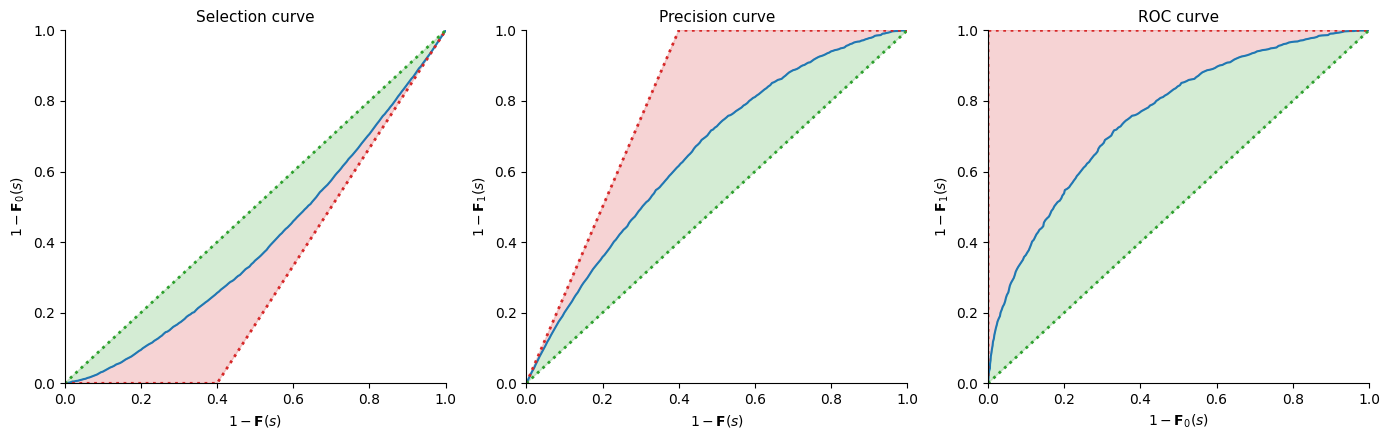

In [17]:
titles = ["Selection curve", "Precision curve", "ROC curve"]
xlabels = [r"$1 - \mathbf{F}(s)$", r"$1 - \mathbf{F}(s)$", r"$1 - \mathbf{F}_0(s)$"]
ylabels = [r"$1 - \mathbf{F}_0(s)$", r"$1 - \mathbf{F}_1(s)$", r"$1 - \mathbf{F}_1(s)$"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for i, (sheet, ax, title, xl, yl) in enumerate(
        zip(["Feuil1", "Feuil2", "Feuil3"], axes, titles, xlabels, ylabels)):
    curve = pd.read_excel(f"{DATA_DIR}/scoring_gini2.xlsx", sheet_name=sheet, header=None).to_numpy()
    x1, x2, y1, y2 = curve[:, 0], curve[:, 1], curve[:, 2], curve[:, 3]
    diag = np.linspace(0, 1, len(curve))

    ax.fill(np.concatenate([x1, x2[::-1]]), np.concatenate([y1, y2[::-1]]),
            color="tab:red", alpha=0.2)
    ax.fill(np.concatenate([x1, diag[::-1]]), np.concatenate([y1, diag[::-1]]),
            color="tab:green", alpha=0.2)
    ax.plot(x1, y1, "-", color="tab:blue", lw=1.5)
    ax.plot(x2, y2, ":", color="tab:red", lw=2.0)
    ax.plot(diag, diag, ":", color="tab:green", lw=2.0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 13. Performance, selection and discriminant curves: user vs. optimal vs. random

From `chap2_scoring_graphical1.m` and `chap2_scoring_ks1.m`. Three
related evaluation curves -- how a score's *performance*, *selection*
and *discriminant* power look for a fitted ("user") score, compared to
the best-possible ("optimal") score and a purely random score -- each
read from their own `.xlsx` file (one sheet per curve type, columns
`[x, y_user, y_optimal, y_random]`). `chap2_scoring_ks1.m` reproduces the
same three curves and adds a fourth panel, the conditional CDFs whose
maximum vertical gap is the Kolmogorov-Smirnov statistic.


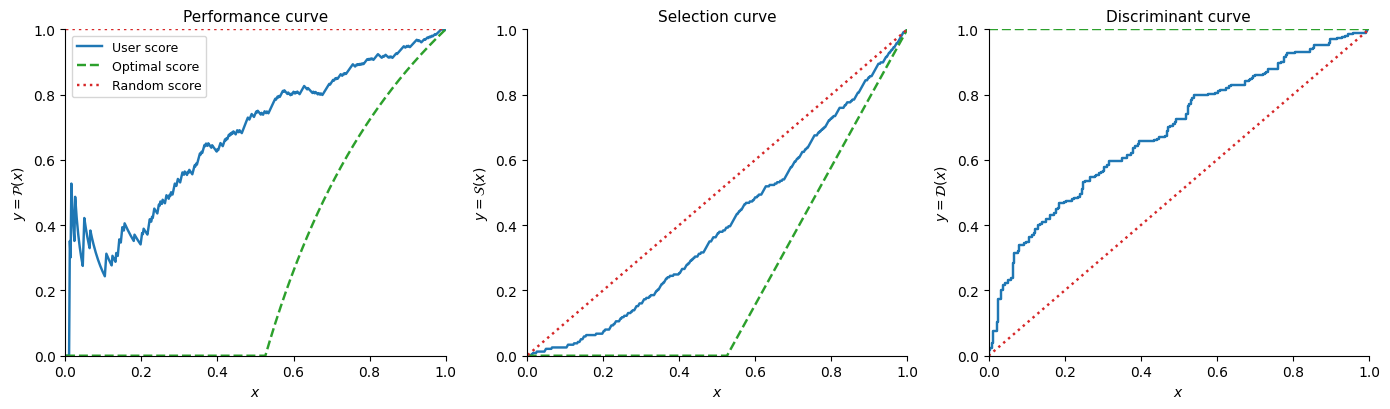

In [18]:
def plot_three_curve_panel(ax, curve, title, ylabel, legend=False):
    x, y = curve[:, 0], curve[:, 1:4]
    labels = ["User score", "Optimal score", "Random score"]
    styles = ["-", "--", ":"]
    colours = ["tab:blue", "tab:green", "tab:red"]
    for i in range(3):
        ax.plot(x, y[:, i], styles[i], color=colours[i], lw=1.75,
                 label=labels[i] if legend else None)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("$x$")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


sheets = {"performance": ("Feuil1", "Performance curve", r"$y = \mathcal{P}(x)$"),
          "selection": ("Feuil2", "Selection curve", r"$y = \mathcal{S}(x)$"),
          "discriminant": ("Feuil3", "Discriminant curve", r"$y = \mathcal{D}(x)$")}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (sheet, title, ylabel) in zip(axes, sheets.values()):
    curve = pd.read_excel(f"{DATA_DIR}/scoring_graphical1.xlsx", sheet_name=sheet, header=None).to_numpy()
    plot_three_curve_panel(ax, curve, title, ylabel, legend=(ax is axes[0]))
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()


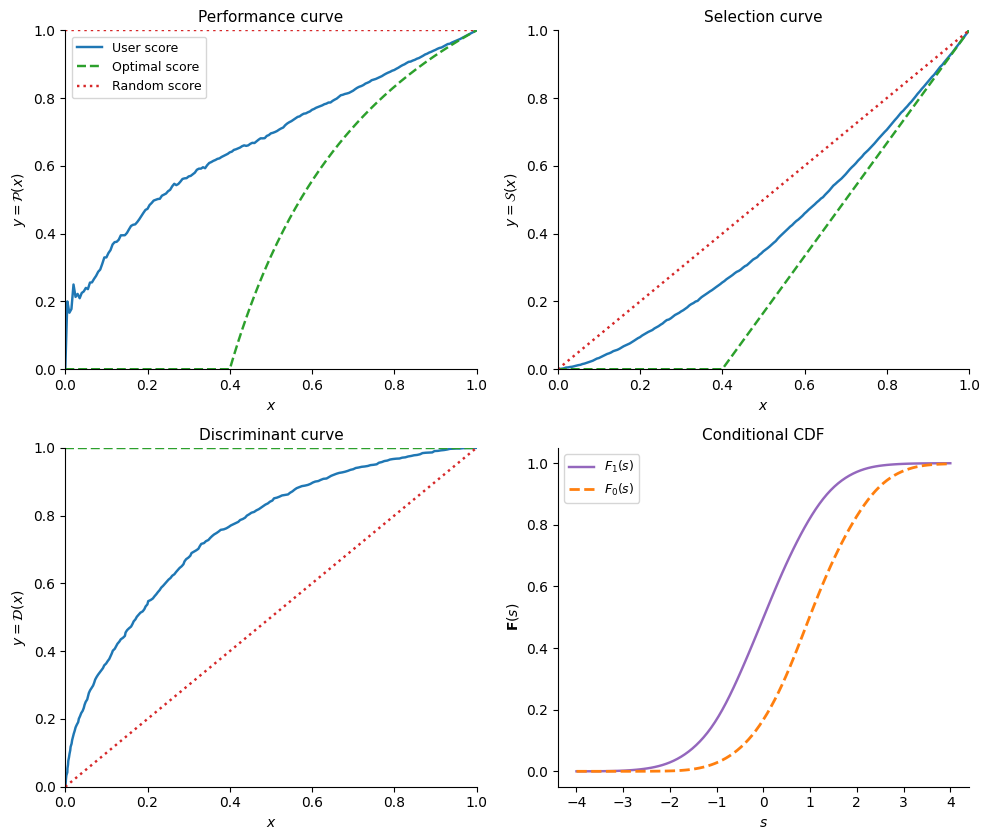

KS statistic: 0.3619


In [19]:
sheets = {"performance": ("Feuil1", "Performance curve", r"$y = \mathcal{P}(x)$"),
          "selection": ("Feuil2", "Selection curve", r"$y = \mathcal{S}(x)$"),
          "discriminant": ("Feuil3", "Discriminant curve", r"$y = \mathcal{D}(x)$")}

fig, axes = plt.subplots(2, 2, figsize=(10, 8.5))
for ax, (sheet, title, ylabel) in zip(axes.ravel()[:3], sheets.values()):
    curve = pd.read_excel(f"{DATA_DIR}/scoring_ks1.xlsx", sheet_name=sheet, header=None).to_numpy()
    plot_three_curve_panel(ax, curve, title, ylabel, legend=(ax is axes.ravel()[0]))
axes.ravel()[0].legend(fontsize=9)

ks_curve = pd.read_excel(f"{DATA_DIR}/scoring_ks1.xlsx", sheet_name="Feuil4", header=None).to_numpy()
ks_curve = ks_curve[~np.isnan(ks_curve[:, 1])]
s, F1, F0 = ks_curve[:, 0], ks_curve[:, 1], ks_curve[:, 2]
ks_stat = np.max(np.abs(F1 - F0))

ax = axes.ravel()[3]
ax.plot(s, F1, "-", color="tab:purple", lw=1.75, label="$F_1(s)$")
ax.plot(s, F0, "--", color="tab:orange", lw=2.0, label="$F_0(s)$")
ax.set_title("Conditional CDF", fontsize=11)
ax.set_xlabel("$s$")
ax.set_ylabel(r"$\mathbf{F}(s)$")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"KS statistic: {ks_stat:.4f}")


## 14. Comparing two scores

From `chap2_scoring_graphical2.m` and `chap2_scoring_graphical3.m`. The
same performance/selection/discriminant curves, but now comparing two
different scores $\mathbf{S}_1$ and $\mathbf{S}_2$ against each other
directly, rather than against an optimal/random benchmark. Each sheet
holds `[x1, x2, y1, y2]` -- one $(x,y)$ curve per score.


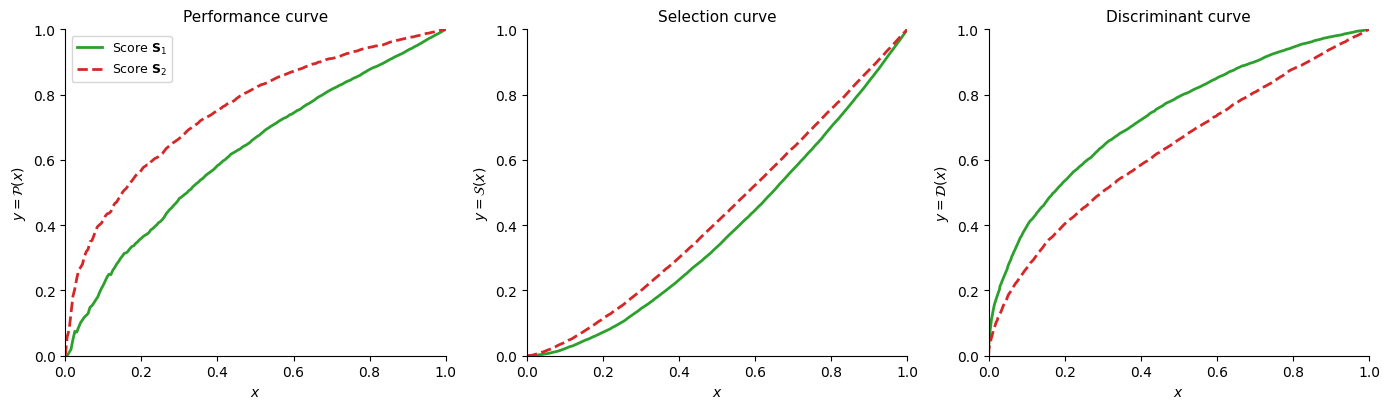

In [20]:
sheets = [("Feuil1", "Performance curve", r"$y = \mathcal{P}(x)$"),
          ("Feuil2", "Selection curve", r"$y = \mathcal{S}(x)$"),
          ("Feuil3", "Discriminant curve", r"$y = \mathcal{D}(x)$")]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (sheet, title, ylabel) in zip(axes, sheets):
    curve = pd.read_excel(f"{DATA_DIR}/scoring_graphical2.xlsx", sheet_name=sheet, header=None).to_numpy()
    x1, x2, y1, y2 = curve[:, 0], curve[:, 1], curve[:, 2], curve[:, 3]
    ax.plot(x1, y1, "-", color="tab:green", lw=2.0, label=r"Score $\mathbf{S}_1$")
    ax.plot(x2, y2, "--", color="tab:red", lw=2.0, label=r"Score $\mathbf{S}_2$")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("$x$")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()


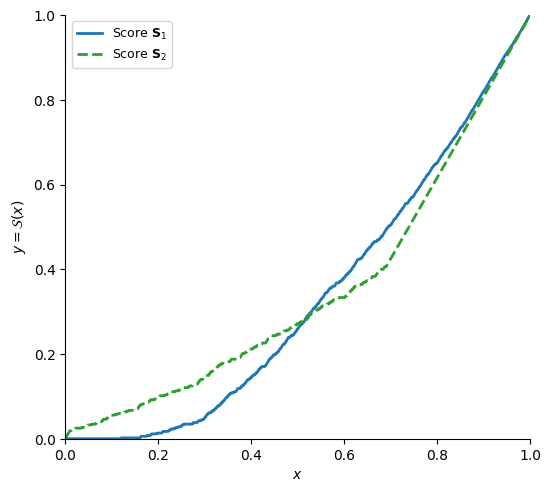

In [21]:
curve = pd.read_excel(f"{DATA_DIR}/scoring_graphical3.xlsx", header=None).to_numpy()
x1, x2, y1, y2 = curve[:, 0], curve[:, 1], curve[:, 2], curve[:, 3]

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(x1, y1, "-", color="tab:blue", lw=2.0, label=r"Score $\mathbf{S}_1$")
ax.plot(x2, y2, "--", color="tab:green", lw=2.0, label=r"Score $\mathbf{S}_2$")
ax.set_xlabel("$x$")
ax.set_ylabel(r"$y = \mathcal{S}(x)$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
plt.show()


## 15. Backtesting scoring rules on real portfolios

From `chap2_scoring_backtesting1.m`-`chap2_scoring_backtesting5.m`.
`scoring_backtesting_msci_{world,em}.xlsx` each hold four sheets (`Worst`,
`Bad`, `Good`, `Best` -- named after four portfolio-construction rules:
worst-in-class exclusion, bad-risk tilt, good-risk tilt, best-in-class
selection), each with a `Score` column and eight metric columns:
accuracy, F1, MCC and a Shannon-entropy-based agreement measure, each
computed at two rebalancing frequencies ($\delta = 3$ and $\delta = 12$
months).

Unlike the curve scripts above, this one has a real computational step:
`chap2_scoring_backtesting*.m` runs each raw metric-vs-score series
through a smoothing cubic spline (MATLAB's `csaps`, smoothing parameter
$p=0.5$) before plotting, to denoise it. Reproduced here with the
[`csaps`](https://pypi.org/project/csaps/) package, a MATLAB-compatible
Python port of the same smoothing-spline algorithm.


In [22]:
def load_backtesting(path):
    sheets = {}
    for name in ["Worst", "Bad", "Good", "Best"]:
        block = pd.read_excel(path, sheet_name=name, header=None, skiprows=2).to_numpy()
        sheets[name] = {"score": block[:, 0], "data": block[:, 1:9]}
    return sheets


def smoothed_metric_panel(sheets, pair, legend_labels, title):
    metric_titles = ["ACC", "$F_1$", "MCC", r"$\mathcal{I}(\mathbf{S}\cap Y)$"]
    x = np.linspace(-2, 2, 201)
    a, b = pair
    fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
    for j, ax in enumerate(axes.ravel()):
        for k, (name, colour, ls) in enumerate(zip(
                [a, a, b, b], ["tab:blue", "tab:red", "tab:green", "tab:purple"],
                ["-", "--", "-", "--"])):
            col = 2 * j + (k % 2)
            score = sheets[name]["score"]
            data = sheets[name]["data"][:, col]
            y = csaps(score, data, x, smooth=0.5)
            ax.plot(x, y, ls, color=colour, lw=1.75,
                     label=legend_labels[k] if j == 0 else None)
        ax.grid(True)
        ax.set_title(metric_titles[j], fontsize=11)
        ax.set_xlabel("$s$")
        ax.set_xlim(-2, 2)
        ax.set_ylim(0, 100)
    axes.ravel()[0].legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


world = load_backtesting(f"{DATA_DIR}/scoring_backtesting_msci_world.xlsx")
em = load_backtesting(f"{DATA_DIR}/scoring_backtesting_msci_em.xlsx")


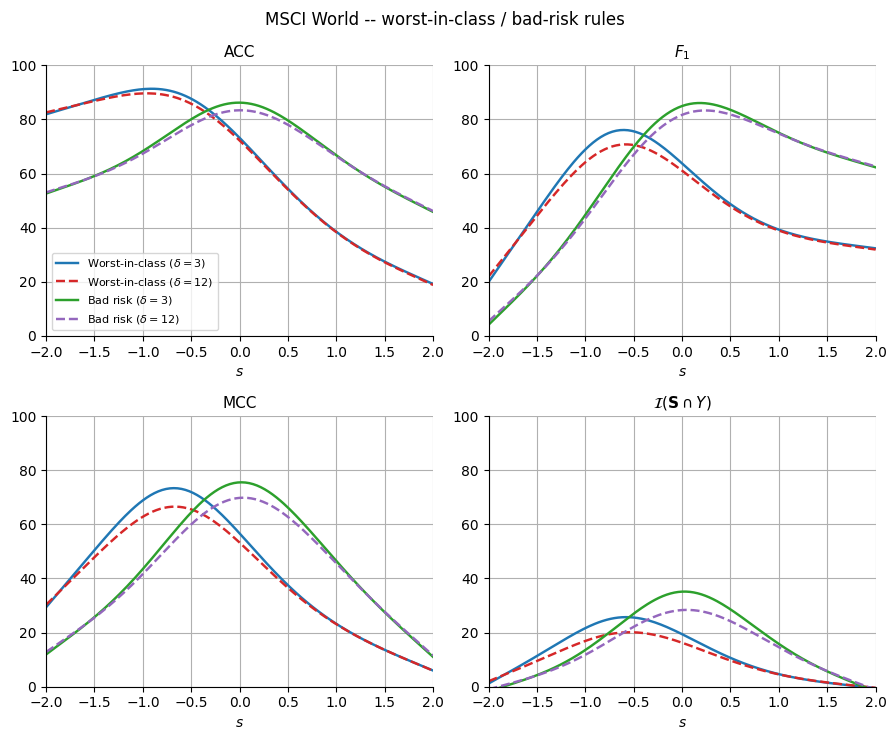

In [23]:
smoothed_metric_panel(
    world, ("Worst", "Bad"),
    ["Worst-in-class ($\\delta=3$)", "Worst-in-class ($\\delta=12$)",
     "Bad risk ($\\delta=3$)", "Bad risk ($\\delta=12$)"],
    "MSCI World -- worst-in-class / bad-risk rules")


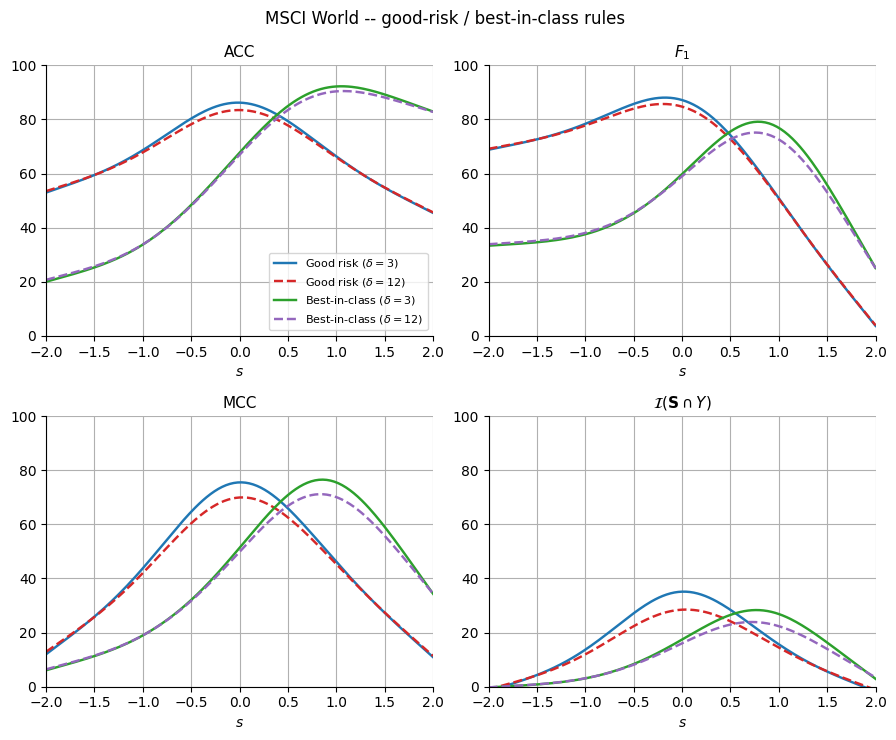

In [24]:
smoothed_metric_panel(
    world, ("Good", "Best"),
    ["Good risk ($\\delta=3$)", "Good risk ($\\delta=12$)",
     "Best-in-class ($\\delta=3$)", "Best-in-class ($\\delta=12$)"],
    "MSCI World -- good-risk / best-in-class rules")


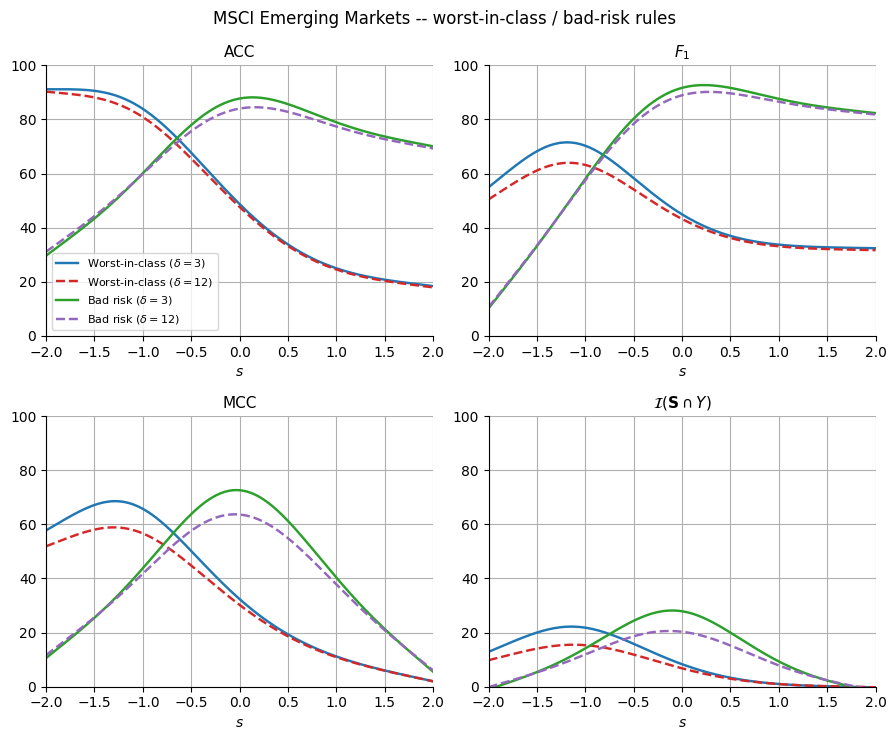

In [25]:
smoothed_metric_panel(
    em, ("Worst", "Bad"),
    ["Worst-in-class ($\\delta=3$)", "Worst-in-class ($\\delta=12$)",
     "Bad risk ($\\delta=3$)", "Bad risk ($\\delta=12$)"],
    "MSCI Emerging Markets -- worst-in-class / bad-risk rules")


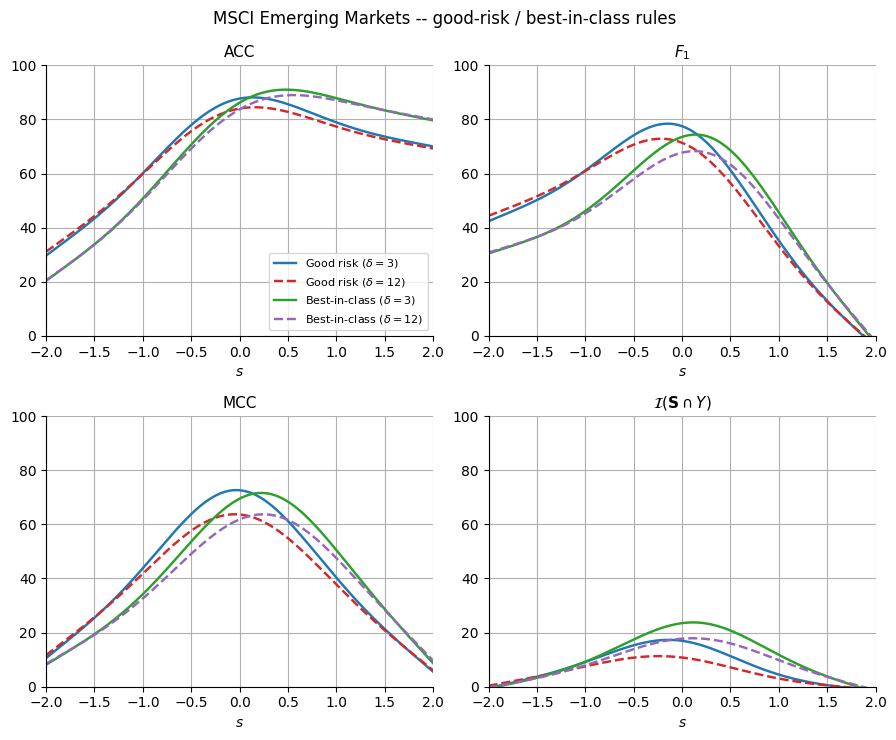

In [26]:
smoothed_metric_panel(
    em, ("Good", "Best"),
    ["Good risk ($\\delta=3$)", "Good risk ($\\delta=12$)",
     "Best-in-class ($\\delta=3$)", "Best-in-class ($\\delta=12$)"],
    "MSCI Emerging Markets -- good-risk / best-in-class rules")


### 15.1 Optimal score threshold per rule

From `chap2_scoring_backtesting5.m`. For each metric and each of the
four sheets, find the score threshold $s^\star$ that maximises the
smoothed metric curve (evaluated on a finer, 4001-point grid), at both
rebalancing frequencies.


In [27]:
def optimal_thresholds(sheets):
    x = np.linspace(-2, 2, 4001)
    rows = []
    for name, sheet in sheets.items():
        score = sheet["score"]
        row = {"rule": name}
        for j, metric in enumerate(["ACC", "F1", "MCC", "Shannon"]):
            for k, delta in enumerate([3, 12]):
                y = csaps(score, sheet["data"][:, 2 * j + k], x, smooth=0.5)
                row[f"{metric} (d={delta})"] = x[np.argmax(y)]
        rows.append(row)
    return pd.DataFrame(rows).set_index("rule")


print("MSCI World")
display(optimal_thresholds(world).round(3))
print("MSCI Emerging Markets")
display(optimal_thresholds(em).round(3))


MSCI World


,ACC (d=3),ACC (d=12),F1 (d=3),F1 (d=12),MCC (d=3),MCC (d=12),Shannon (d=3),Shannon (d=12)
rule,,,,,,,,
Worst,-0.909,-0.959,-0.605,-0.582,-0.679,-0.670,-0.578,-0.540
Bad,-0.007,0.008,0.183,0.239,0.018,0.039,0.024,0.049
Good,-0.018,-0.007,-0.176,-0.199,0.010,0.028,0.017,0.040
Best,1.053,1.076,0.787,0.757,0.855,0.835,0.767,0.720


MSCI Emerging Markets


,ACC (d=3),ACC (d=12),F1 (d=3),F1 (d=12),MCC (d=3),MCC (d=12),Shannon (d=3),Shannon (d=12)
rule,,,,,,,,
Worst,-1.866,-2.000,-1.189,-1.171,-1.286,-1.302,-1.145,-1.121
Bad,0.133,0.161,0.226,0.281,-0.034,-0.050,-0.103,-0.136
Good,0.132,0.160,-0.149,-0.217,-0.034,-0.050,-0.141,-0.240
Best,0.479,0.557,0.141,0.129,0.224,0.245,0.114,0.108


## 16. Case study: the Living Planet Index

From `chap2_lpi1.m`. The WWF Living Planet Index tracks the average
relative change in monitored vertebrate population sizes since 1970
(indexed to $1.0$). Fit with a smoothing spline (`scipy`'s
`UnivariateSpline`, standing in for MATLAB's `fit(...,
'smoothingspline', ...)`) both to the level and to its first derivative
(the annual rate of change), plus the published confidence interval.


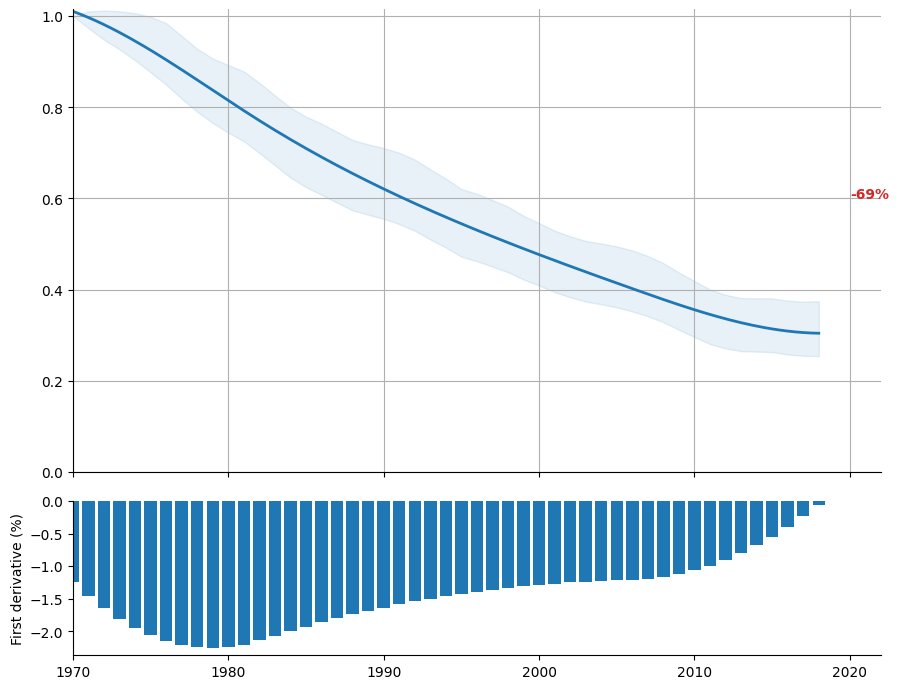

Total change 1970-2018: -69.9%


In [28]:
from scipy.interpolate import UnivariateSpline

lpi = pd.read_excel(f"{DATA_DIR}/lpi_2022.xlsx")
year = lpi["Year"].to_numpy(dtype=float)
lpi_index = lpi["LPI_final"].to_numpy(dtype=float)
lpi_ci = lpi[["CI_low", "CI_high"]].to_numpy(dtype=float)

spline = UnivariateSpline(year, lpi_index, s=len(year) * 5e-5)
x_fit = np.arange(1970, 2018.25, 0.25)
y_fit = spline(x_fit)
x_years = np.arange(1970, 2019)
dy_fit = spline.derivative()(x_years)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

ax = axes[0]
ax.plot(x_fit, y_fit, "-", color="tab:blue", lw=2.0)
ax.fill_between(year, lpi_ci[:, 0], lpi_ci[:, 1], color="tab:blue", alpha=0.10)
total_change = y_fit[-1] / y_fit[0] - 1
ax.annotate(f"{int(100*total_change)}%", xy=(2020, 0.6), color="tab:red", fontweight="bold")
ax.grid(True)
ax.set_xlim(1970, 2022)
ax.set_ylim(0, 1.015)

ax = axes[1]
ax.bar(x_years, 100 * dy_fit, color="tab:blue")
ax.set_xlim(1970, 2022)
ax.set_ylabel("First derivative (%)")
plt.tight_layout()
plt.show()

print(f"Total change {year[0]:.0f}-{year[-1]:.0f}: {100*total_change:.1f}%")


## 17. Case study: the Red List Index

From `chap2_rli1.m`. The IUCN Red List Index tracks extinction risk
across a country's assessed species ($1.0$ = least concern for all
species, $0.0$ = all extinct). Six countries' RLI series, each smoothed
with the same spline approach as the LPI above, ranked by their most
recent value.


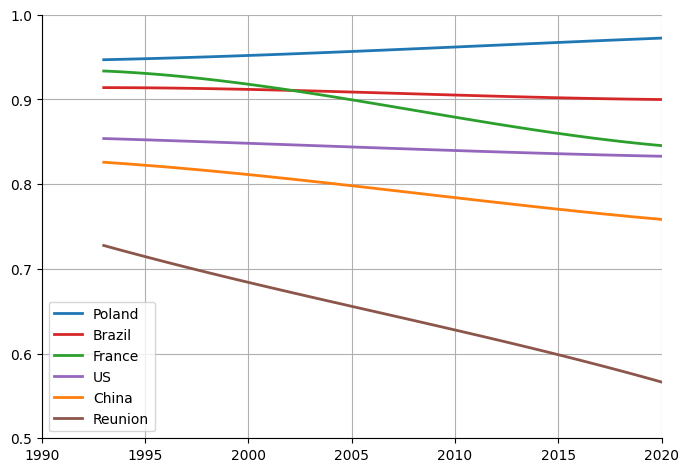

In [29]:
countries = {"Poland": "POL", "Brazil": "BRA", "France": "FRA",
             "US": "USA", "China": "CHN", "Reunion": "Reunion"}
sheet_by_country = {"Poland": "Poland", "Brazil": "Brazil", "France": "France",
                     "US": "US", "China": "China", "Reunion": "Reunion"}

series = {}
for name, sheet in sheet_by_country.items():
    df = pd.read_excel(f"{DATA_DIR}/rli_2022.xlsx", sheet_name=sheet).dropna(subset=["rli"])
    series[name] = (df["year"].to_numpy(dtype=float), df["rli"].to_numpy(dtype=float))

order = sorted(series, key=lambda n: series[n][1][-1], reverse=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
colours = ["tab:blue", "tab:red", "tab:green", "tab:purple", "tab:orange", "tab:brown"]
for name, colour in zip(order, colours):
    x, y = series[name]
    spline = UnivariateSpline(x, y, s=len(x) * 1e-5)
    x_fit = np.arange(x.min(), x.max() + 0.25, 0.25)
    ax.plot(x_fit, spline(x_fit), "-", color=colour, lw=2.0, label=name)
ax.grid(True)
ax.set_xlim(1990, 2020)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=10, loc="lower left")
plt.show()
